# OpenSim Pendulum: Torque Application

In this second tutorial on the OpenSim pendulum, we extend the basic model by applying an external torque at the pivot using a `CoordinateActuator`.

1. **[Basics](01_opensim_pendulum_basics.ipynb)**: We set up a single-link pendulum with a pin joint and simulate its free swing under gravity.
2. **Torque Application** (this tutorial): We extend the model by applying an external torque via a `CoordinateActuator`.
3. **[Contact Handling](03_opensim_pendulum_contact.ipynb)**: We further extend the model by adding contact geometry and forces.

## Overview

This tutorial adds a **torque input** to the rigid-body pendulum from Tutorial 01.

Core ideas:
1. Add a `CoordinateActuator` that applies a generalized force (torque) along the pin joint coordinate $\theta$.
2. Use `overrideActuation` to set the torque value directly at each time step, bypassing the controller/excitation pathway.
3. Simulate the pendulum with a constant torque (gravity off and on) and extract time-series results.
4. Verify the OpenSim results against an analytical rigid-body prediction.
5. Compare different torque magnitudes in a parameter study.

## Learning Goals
- Add a `CoordinateActuator` to an OpenSim model
- Understand the **actuation override** mechanism for direct torque control
- Simulate with a constant applied torque and extract kinematic outputs
- Verify simulation results against a rigid-body ODE solution
- Compare torque-driven motion with and without gravity

## Prerequisites and Setup

This notebook assumes you have completed [Tutorial 01 — Basics](01_opensim_pendulum_basics.ipynb) and are familiar with:
- Creating bodies, joints, and coordinates in OpenSim
- Running forward dynamics with the `Manager`
- Extracting coordinate values from the simulation state

**Background — CoordinateActuator and Actuation Override**

In OpenSim, forces are normally computed from controls (e.g., muscle excitations) through internal dynamics. For direct torque application, the `CoordinateActuator` class provides a simpler pathway:

- A `CoordinateActuator` applies a scalar generalized force along a single coordinate (here, the pin joint angle $\theta$).
- By calling `overrideActuation(state, True)`, we bypass the normal control-to-force pipeline.
- We then set the torque value directly with `setOverrideActuation(state, torque_value)`.

This is equivalent to specifying $\tau$ in the equation of motion:

$$I\,\ddot{\theta} = -m\,g\,L\,\sin(\theta) + \tau$$

where $\tau$ is the value we set via `setOverrideActuation`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import opensim as osim
from scipy.integrate import solve_ivp

## Model Parameters

We use parameters that match the FEM torque tutorial for cross-tool comparison. All quantities are in SI units.

In [2]:
mass = 40.0          # mass of the pendulum head [kg]
r_head = 0.05        # radius of the pendulum head (visualization) [m]
length = 0.5         # length of the pendulum rod [m]
inertia_head = 20.0  # moment of inertia of the head about Z-axis [kg·m²]
g_val = 9.81         # gravitational acceleration [m/s²]

## Building the OpenSim Model

The model construction follows Tutorial 01 (ground → base body → weld joint → head body → pin joint → rod geometry). The key addition is the `CoordinateActuator`.

In [3]:
def build_pendulum_model(use_gravity=True):
    """Build the OpenSim pendulum model with a CoordinateActuator.
    
    Returns the model, coordinate, and actuator objects.
    """
    model = osim.Model()
    model.setName('Pendulum')
    if use_gravity:
        model.setGravity(osim.Vec3(0, -g_val, 0))
    else:
        model.setGravity(osim.Vec3(0, 0, 0))

    ground = model.getGround()

    # --- Base body (fixed pivot) ---
    base = osim.Body("pendulum_base", 1.0, osim.Vec3(0), osim.Inertia(0, 0, 0))
    base_geom = osim.Brick(osim.Vec3(0.1, 0.01, 0.1))
    base_geom.setColor(osim.Vec3(0.8, 0.2, 0.2))
    base.attachGeometry(base_geom)
    model.addBody(base)

    base_to_ground = osim.WeldJoint(
        "base_to_ground",
        ground, osim.Vec3(0, 1.2 * length, 0), osim.Vec3(0),
        base, osim.Vec3(0), osim.Vec3(0),
    )
    model.addJoint(base_to_ground)

    # --- Pendulum head body ---
    head = osim.Body("pendulum_head", mass, osim.Vec3(0), osim.Inertia(0, 0, inertia_head))
    head_geom = osim.Sphere(r_head)
    head_geom.setColor(osim.Vec3(0.2, 0.2, 0.8))
    head.attachGeometry(head_geom)
    model.addBody(head)

    head_to_base = osim.PinJoint(
        "head_to_base",
        base, osim.Vec3(0), osim.Vec3(0),
        head, osim.Vec3(0, length, 0), osim.Vec3(0),
    )
    model.addJoint(head_to_base)

    # --- Rod visualization ---
    head_of = osim.PhysicalOffsetFrame()
    head_of.setName("head_of")
    head_of.setParentFrame(head)
    head_of.set_translation(osim.Vec3(0, length / 2, 0))
    head_of_geom = osim.Cylinder(r_head / 4, length / 2)
    head_of_geom.setColor(osim.Vec3(0.2, 0.8, 0.2))
    head_of.attachGeometry(head_of_geom)
    head.addComponent(head_of)

    # --- Coordinate setup ---
    coord = head_to_base.getCoordinate()
    coord.setName("theta")

    # --- CoordinateActuator (torque input) ---
    actuator = osim.CoordinateActuator()
    actuator.setName("torque")
    actuator.setCoordinate(coord)
    actuator.setOptimalForce(1)      # gain = 1 → actuation value = torque in N·m
    actuator.setMinControl(-1e6)
    actuator.setMaxControl(1e6)
    model.addForce(actuator)

    model.finalizeConnections()

    return model, coord, actuator

### The CoordinateActuator

A `CoordinateActuator` applies a generalized force along a single coordinate. Key configuration:

| Method | Purpose |
|--------|---------|
| `setCoordinate(coord)` | Binds the actuator to the pin joint coordinate $\theta$ |
| `setOptimalForce(1)` | Sets the gain to 1, so the actuation value equals the torque in N·m |
| `setMinControl / setMaxControl` | Sets the allowed range for torque (large bounds for unconstrained actuation) |
| `overrideActuation(state, True)` | Enables direct torque specification, bypassing the control pathway |
| `setOverrideActuation(state, τ)` | Sets the torque value $\tau$ for the current state |



> **Note:** `overrideActuation` must be called **after** `model.initSystem()` because it modifies the `State` object.

## Simulation Helper

We encapsulate the simulation loop in a reusable function. At each reporting step, we:
1. Set the override actuation to the desired torque value.
2. Integrate to the next time point.
3. Realize accelerations and extract $\theta$, $\dot\theta$, $\ddot\theta$.

In [4]:
def simulate_pendulum(model, coord, actuator, torque_func,
                      q0=0.0, omega0=0.0, dt=0.001, t_end=5.0):
    """Run a forward dynamics simulation with a time-varying torque.
    
    Parameters
    ----------
    model : osim.Model
    coord : osim.Coordinate
    actuator : osim.CoordinateActuator
    torque_func : callable
        Function torque_func(t) -> float returning the torque in N·m.
    q0 : float
        Initial angle [rad].
    omega0 : float
        Initial angular velocity [rad/s].
    dt : float
        Reporting interval [s].
    t_end : float
        End time [s].
        
    Returns
    -------
    dict with keys 'time', 'theta', 'omega', 'alpha'.
    """
    # Set initial conditions
    coord.setDefaultValue(q0)
    coord.setDefaultSpeedValue(omega0)

    state = model.initSystem()

    # Enable direct torque override
    actuator.overrideActuation(state, True)
    actuator.setOverrideActuation(state, torque_func(0.0))

    model.realizeAcceleration(state)

    manager = osim.Manager(model)
    manager.initialize(state)

    t_vals, theta_vals, omega_vals, alpha_vals = [], [], [], []

    t = 0.0
    while t < t_end - 1e-8:
        # Set torque for the upcoming integration interval
        actuator.setOverrideActuation(state, torque_func(t))

        state = manager.integrate(t + dt)
        model.realizeAcceleration(state)

        t_vals.append(state.getTime())
        theta_vals.append(coord.getValue(state))
        omega_vals.append(coord.getSpeedValue(state))
        alpha_vals.append(coord.getAccelerationValue(state))

        t = state.getTime()

    return {
        'time': np.array(t_vals),
        'theta': np.array(theta_vals),
        'omega': np.array(omega_vals),
        'alpha': np.array(alpha_vals),
    }

## Analytical Reference Solution

To verify the OpenSim results, we solve the rigid-body ODE

$$I\,\ddot{\theta} = \tau - m\,g\,L\,\sin(\theta)$$

using `scipy.integrate.solve_ivp` with a high-accuracy Runge-Kutta method.

In [5]:
def solve_rigid_pendulum(torque_val, q0, omega0, t_end, dt, use_gravity=True):
    """Solve the rigid-body pendulum ODE for verification."""
    g = g_val if use_gravity else 0.0

    def dynamics(t, y):
        theta, omega = y
        alpha = (torque_val - mass * g * length * np.sin(theta)) / (mass * length**2 + inertia_head)
        return [omega, alpha]

    t_eval = np.arange(0.0, t_end + dt, dt)
    sol = solve_ivp(dynamics, [0.0, t_end + dt], [q0, omega0],
                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0], sol.y[1]

## Simulation Parameters

In [6]:
q0 = np.deg2rad(0)    # initial angle [rad]
omega0 = 0.0           # initial angular velocity [rad/s]
dt = 0.001             # reporting interval [s]
t_end = 3.0            # end time [s]
Mz = 20.0              # constant applied torque [N·m]

## Constant Torque Without Gravity

We first disable gravity to isolate the effect of the applied torque. With $g=0$ and constant torque $\tau$, the analytical solution is a uniform angular acceleration:

$$\ddot\theta = \frac{\tau}{I}, \qquad \theta(t) = \theta_0 + \omega_0\,t + \frac{1}{2}\frac{\tau}{I}\,t^2.$$

This provides a clean verification of the `CoordinateActuator` setup.

In [7]:
model_ng, coord_ng, actuator_ng = build_pendulum_model(use_gravity=False)

res_ng = simulate_pendulum(
    model_ng, coord_ng, actuator_ng,
    torque_func=lambda t: Mz,
    q0=q0, omega0=omega0, dt=dt, t_end=t_end,
)

t_ref_ng, theta_ref_ng, omega_ref_ng = solve_rigid_pendulum(
    Mz, q0, omega0, t_end, dt, use_gravity=False,
)

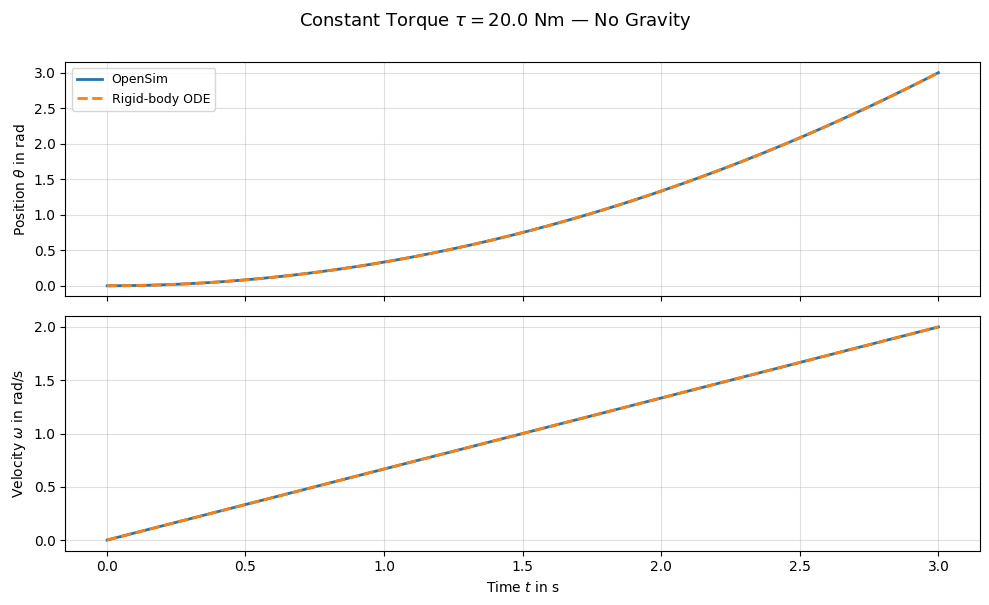

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(res_ng['time'], res_ng['theta'], label='OpenSim', linewidth=2)
axes[0].plot(t_ref_ng, theta_ref_ng, '--', label='Rigid-body ODE', linewidth=2)
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper left', fontsize=9, frameon=True)
axes[0].grid(True, alpha=0.4)

axes[1].plot(res_ng['time'], res_ng['omega'], label='OpenSim', linewidth=2)
axes[1].plot(t_ref_ng, omega_ref_ng, '--', label='Rigid-body ODE', linewidth=2)
axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[0].legend(loc='upper left', fontsize=9, frameon=True)
axes[1].grid(True, alpha=0.4)

fig.suptitle(rf'Constant Torque $\tau = {Mz}$ Nm — No Gravity', fontsize=13, y=1)
plt.tight_layout()
plt.show()

The OpenSim simulation matches the analytical prediction exactly. With no gravity and a constant torque, the pendulum accelerates uniformly. This confirms that the `CoordinateActuator` with `overrideActuation` correctly applies the specified torque.

## Constant Torque With Gravity

Now we enable gravity. The equation of motion becomes nonlinear due to the $\sin(\theta)$ term:

$$I\,\ddot{\theta} = \tau - m\,g\,L\,\sin(\theta)$$

The pendulum will initially accelerate under the applied torque, but gravity provides a restoring (or opposing) moment depending on the angle.

In [9]:
model_g, coord_g, actuator_g = build_pendulum_model(use_gravity=True)

res_g = simulate_pendulum(
    model_g, coord_g, actuator_g,
    torque_func=lambda t: Mz,
    q0=q0, omega0=omega0, dt=dt, t_end=t_end,
)

t_ref_g, theta_ref_g, omega_ref_g = solve_rigid_pendulum(
    Mz, q0, omega0, t_end, dt, use_gravity=True,
)

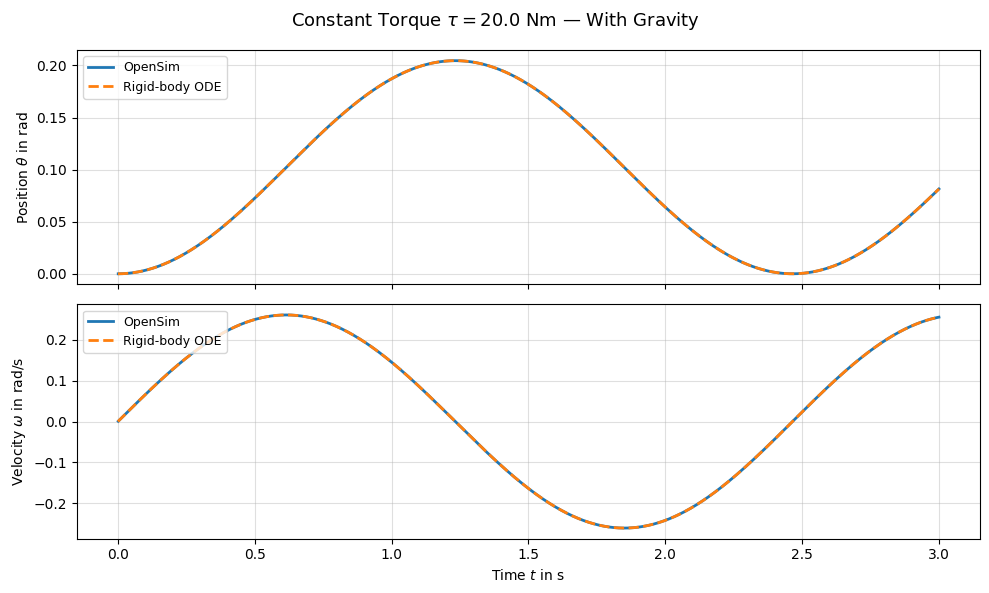

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(res_g['time'], res_g['theta'], label='OpenSim', linewidth=2)
axes[0].plot(t_ref_g, theta_ref_g, '--', label='Rigid-body ODE', linewidth=2)
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper left', fontsize=9, frameon=True)
axes[0].grid(True, alpha=0.4)

axes[1].plot(res_g['time'], res_g['omega'], label='OpenSim', linewidth=2)
axes[1].plot(t_ref_g, omega_ref_g, '--', label='Rigid-body ODE', linewidth=2)
axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[1].legend(loc='upper left', fontsize=9, frameon=True)
axes[1].grid(True, alpha=0.4)

fig.suptitle(rf'Constant Torque $\tau = {Mz}$ Nm — With Gravity', fontsize=13)
plt.tight_layout()
plt.show()

Again, the OpenSim results closely match the rigid-body ODE solution. The nonlinear interaction between the applied torque and gravity is correctly captured. Whether the torque is sufficient to drive the pendulum over the top depends on the ratio $\tau / (m g L)$.

## Comparison: Gravity On vs. Off

We overlay both cases to highlight the effect of gravity on the torque-driven motion.

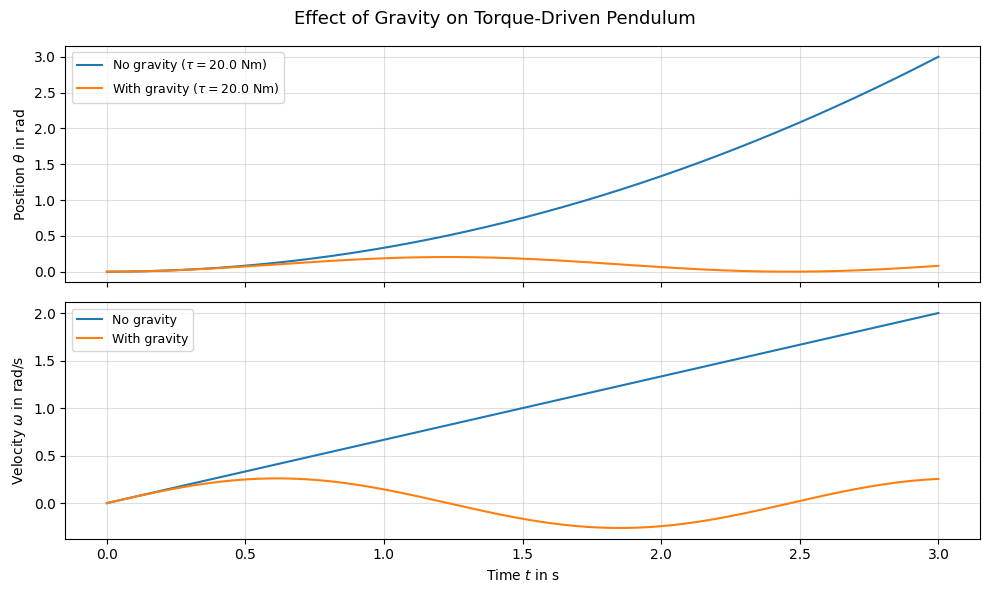

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(res_ng['time'], res_ng['theta'],
             label=rf'No gravity ($\tau = {Mz}$ Nm)', linewidth=1.5)
axes[0].plot(res_g['time'], res_g['theta'],
             label=rf'With gravity ($\tau = {Mz}$ Nm)', linewidth=1.5)
axes[0].set_ylabel(r'Position $\theta$ in rad')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].plot(res_ng['time'], res_ng['omega'],
             label='No gravity', linewidth=1.5)
axes[1].plot(res_g['time'], res_g['omega'],
             label='With gravity', linewidth=1.5)
axes[1].set_ylabel(r'Velocity $\omega$ in rad/s')
axes[1].set_xlabel(r'Time $t$ in s')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.4)

fig.suptitle('Effect of Gravity on Torque-Driven Pendulum', fontsize=13)
plt.tight_layout()
plt.show()

Without gravity, the pendulum accelerates monotonically under the constant torque. With gravity, the gravitational moment opposes or assists the motion depending on the angle, producing a more complex trajectory.

## Visualize the Motion

We can replay one of the simulations in the OpenSim visualizer.

In [12]:
# Rebuild and simulate for visualization (medium torque, with gravity)
model_viz, coord_viz, actuator_viz = build_pendulum_model(use_gravity=True)

coord_viz.setDefaultValue(q0)
coord_viz.setDefaultSpeedValue(omega0)
state_viz = model_viz.initSystem()
actuator_viz.overrideActuation(state_viz, True)
actuator_viz.setOverrideActuation(state_viz, Mz)
model_viz.realizeAcceleration(state_viz)

manager_viz = osim.Manager(model_viz)
manager_viz.initialize(state_viz)

t = 0.0
while t < t_end - 1e-8:
    actuator_viz.setOverrideActuation(state_viz, Mz)
    state_viz = manager_viz.integrate(t + dt)
    t = state_viz.getTime()

In [13]:
import sys
if sys.platform == 'win32':
    states_table = manager_viz.getStatesTable()
    visualizer = osim.VisualizerUtilities()
    visualizer.showMotion(model_viz, states_table)

## Save Model

We can write the model to an `.osim` file for use in the OpenSim GUI or for later reference.

In [14]:
model_viz.printToXML("pendulum_torque.osim")

True

## Conclusion

In this tutorial we:
- Added a `CoordinateActuator` to apply a generalized torque along the pin joint coordinate.
- Used `overrideActuation` to set the torque value directly at each time step, providing full control over the applied moment.
- Verified the implementation against an analytical rigid-body ODE solution — both with and without gravity.

The actuation override mechanism is the key building block for co-simulation scenarios where an external controller or another simulation tool provides the torque signal at each communication step.

Next: [Tutorial 03 — Contact Handling](03_opensim_pendulum_contact.ipynb), where we add contact geometry and forces to the pendulum.